# Glass box / black box optimization with the trust-region filter

Most process models are algebra you can differentiate. Some have one piece that
isn't: a CFD solve, a converged unit model, a trained network. Something you can
*call* but cannot hand to an NLP solver as equations.

`pounce.trf_minimize` solves

$$\min_x f(x) \quad \text{s.t.}\quad h(x)=0,\; g(x)\le 0,\; y = d(w)$$

where $f, h, g$ are the **glass box** and $d$ is the **black box**; $w$ and $y$
are subvectors of $x$.

This notebook shows why the obvious approach fails, what the method does
instead, and how to choose its one real knob.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pounce

print("pounce", pounce.__version__)

pounce 0.9.0


## Why not just fit a surrogate and optimize it?

Because it fails, and it fails *quietly*. Take

$$\min\; x_1^2 + x_2^2 \quad \text{s.t.}\quad x_2 = x_1^3 + x_1^2 + 1$$

with solution $(0, 1)$, $f = 1$. Replace the cubic with a linear surrogate
$x_2 = x_1 + b$, fit $b$ so the surrogate matches the truth model at the current
point, optimize, refit, repeat.

Start it **exactly at the optimum** and watch what happens.

In [2]:
def truth(w):
    """The black box: x2 = x1**3 + x1**2 + 1."""
    return np.array([w[0] ** 3 + w[0] ** 2 + 1.0])

def truth_jac(w):
    return np.array([[3 * w[0] ** 2 + 2 * w[0]]])

f = lambda v: v[0] ** 2 + v[1] ** 2
f_jac = lambda v: np.array([2 * v[0], 2 * v[1]])

# Naive loop: match the surrogate's VALUE at x_k, optimize, repeat.
x = np.array([0.0, 1.0])          # start at the global optimum
naive_path = [x.copy()]
for _ in range(12):
    b = truth(x[:1])[0] - x[0]     # value match at x_k
    r = pounce.minimize(
        f, x, jac=f_jac,
        constraints=[{"type": "eq",
                      "fun": lambda v, b=b: np.array([v[1] - (v[0] + b)]),
                      "jac": lambda v: np.array([[-1.0, 1.0]])}],
    )
    x = np.asarray(r.x)
    naive_path.append(x.copy())

print(f"started at (0, 1) with f = 1.0")
print(f"naive loop ended at ({x[0]:.4f}, {x[1]:.4f}) with f = {f(x):.4f}")

started at (0, 1) with f = 1.0
naive loop ended at (-1.0000, 1.0000) with f = 2.0000


It walked *away* from the optimum and doubled the objective. The point it found,
$(-1, 1)$, is a local **maximum** of the real problem.

This is Biegler (2024) Fig. 2a. The reason is that matching *values* buys you
feasibility, but optimality is a statement about *gradients* — and nothing in
the loop constrains those.

In [3]:
res = pounce.trf_minimize(
    fun=f, x0=[0.0, 1.0],
    truth_model=truth, w_index=[0], y_index=[1],
    jac=f_jac, truth_jac=truth_jac,
)
print(res)
print(f"x = {res.x},  f = {res.fun:.10f}")

TRFResult(success=True, fun=1, theta=0, nit=1, n_truth_evals=1)
x = [0. 1.],  f = 1.0000000000


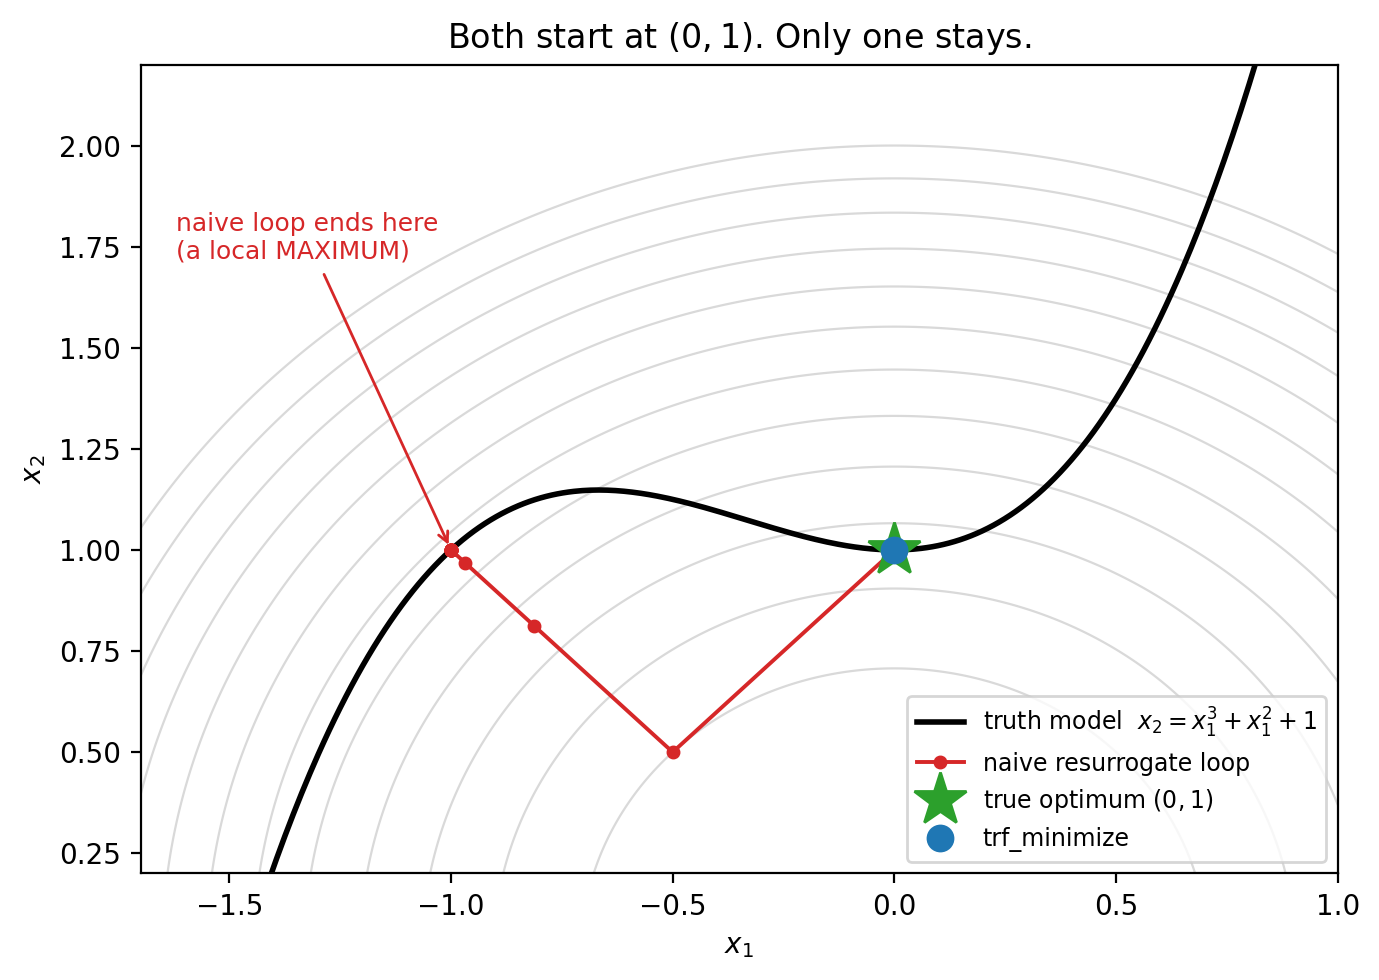

In [4]:
t = np.linspace(-1.6, 0.9, 400)
curve = t**3 + t**2 + 1

fig, ax = plt.subplots(figsize=(7, 5))
# objective contours
gx, gy = np.meshgrid(np.linspace(-1.7, 1.0, 300), np.linspace(0.2, 2.2, 300))
ax.contour(gx, gy, gx**2 + gy**2, levels=np.linspace(0.5, 4, 12),
           colors="0.85", linewidths=0.8, zorder=0)

ax.plot(t, curve, "k-", lw=2, label=r"truth model  $x_2 = x_1^3+x_1^2+1$")
P = np.array(naive_path)
ax.plot(P[:, 0], P[:, 1], "o-", color="tab:red", ms=4, lw=1.4,
        label="naive resurrogate loop")
ax.plot(0, 1, "*", color="tab:green", ms=20, zorder=5, label="true optimum $(0,1)$")
ax.plot(res.x[0], res.x[1], "o", color="tab:blue", ms=9, zorder=6,
        label="trf_minimize")
ax.annotate("naive loop ends here\n(a local MAXIMUM)", xy=(-1, 1),
            xytext=(-1.62, 1.72), fontsize=9, color="tab:red",
            arrowprops=dict(arrowstyle="->", color="tab:red"))
ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")
ax.set_title("Both start at $(0,1)$. Only one stays.")
ax.legend(loc="lower right", fontsize=8.5); ax.set_ylim(0.2, 2.2)
plt.tight_layout(); plt.show()

## What the method actually does

At each iteration it builds a **corrected** surrogate at the current point $w_k$:

$$r_k(w) = \bar r(w) + \underbrace{\big(d(w_k) - \bar r(w_k)\big)}_{\text{ZOC}}
        + \underbrace{\big(J_d(w_k) - J_{\bar r}(w_k)\big)(w - w_k)}_{\text{FOC}}$$

The zero- and first-order corrections force $r_k(w_k) = d(w_k)$ **and**
$J_{r_k}(w_k) = J_d(w_k)$ — for *any* differentiable basis $\bar r$. That second
identity is what the naive loop was missing.

Then it solves an ordinary NLP with $d$ replaced by $r_k$ and the trust region
imposed as *bounds*, evaluates the truth model at the trial point, and accepts
or rejects via a filter on $(\theta, f)$ where $\theta = \lVert y - d(w)\rVert$.

The identities hold even for a deliberately terrible basis:

In [5]:
from pounce.trf import CorrectedSurrogate, QuadraticBasis, quadratic_design

w_k  = np.array([0.3, -0.4])
d_k  = np.array([1.25])          # what the truth model says at w_k
Jd_k = np.array([[2.0, -3.0]])   # and its Jacobian there

# A basis fitted to complete nonsense -- values near 7, nothing to do with d.
D = quadratic_design(w_k, 0.1)
rng = np.random.default_rng(0)
bad_basis = QuadraticBasis().fit(D, 7.0 + rng.normal(size=(len(D), 1)))
r_k = CorrectedSurrogate(bad_basis, w_k, d_k, Jd_k)

print(f"raw basis at w_k   : {bad_basis.predict(w_k)}   <- nowhere near {d_k}")
print(f"corrected at w_k   : {r_k.predict(w_k)}   target {d_k}")
print(f"corrected J at w_k : {r_k.jacobian(w_k)}   target {Jd_k}")

raw basis at w_k   : [7.12573022]   <- nowhere near [1.25]
corrected at w_k   : [1.25]   target [1.25]
corrected J at w_k : [[ 2. -3.]]   target [[ 2. -3.]]


## Choosing a basis

$\bar r$ affects **efficiency, not correctness**. Better curvature means fewer
iterations; a poor basis still converges.

Two findings worth internalizing before reaching for something sophisticated:

* **Fit quality does not predict optimization performance.** Pedrozo et al.
  (2025) benchmarked five surrogate families on a CO₂ pooling problem. RBFs had
  the best $R^2$ of any model and needed 8 TRF iterations; Kriging needed 2.
* **Simple often wins outright.** On Williams-Otto, Eason & Biegler (2016) found
  linear interpolation beat Kriging by 91 truth-model calls to 3141.

Here is the trade-off on a small problem — note that the cost that matters is
`n_truth_evals`, not iterations:

In [6]:
sine = dict(
    fun=lambda v: (v[1] - 1.0) ** 2 + v[0] ** 2,
    x0=[0.5, 0.0],
    truth_model=lambda w: np.sin(w),
    w_index=[0], y_index=[1],
    jac=lambda v: np.array([2 * v[0], 2 * (v[1] - 1.0)]),
)
analytic = lambda w: np.cos(w).reshape(1, 1)

rows = []
for basis in ("zero", "quadratic"):
    for label, tj in (("analytic", analytic), ("finite-diff", None)):
        r = pounce.trf_minimize(**sine, truth_jac=tj, basis=basis, max_iterations=60)
        rows.append((basis, label, r.nit, r.n_truth_evals, r.fun))

print(f"{'basis':<11}{'truth jac':<13}{'iters':>6}{'truth evals':>13}{'f':>18}")
print("-" * 61)
for b, lb, nit, ne, fv in rows:
    print(f"{b:<11}{lb:<13}{nit:>6}{ne:>13}{fv:>18.12f}")

basis      truth jac     iters  truth evals                 f
-------------------------------------------------------------
zero       analytic          7            8    0.520078332823
zero       finite-diff       7           15    0.520078332829
quadratic  analytic          3           10    0.520078332823
quadratic  finite-diff       4           13    0.520078332848


Read that table carefully, because the obvious reading is the wrong one.

`quadratic` converges in **3 iterations against `zero`'s 7** — it captures
curvature the linearization misses. But it costs **more** truth-model calls to
do it (10 vs 8), because each iteration re-samples a full quadratic design.
Iterations are not the cost that matters; truth-model calls are. And the sample
count grows as $(n_w{+}1)(n_w{+}2)/2$ — 66 per iteration at $n_w = 10$.

`truth_jac` is the other option that pays: it takes the `zero` run from 15 truth
calls to 8, because a finite-difference Jacobian needs $n_w$ extra evaluations
per iteration and the analytic one needs none.

### Why there is no `"linear"`

You may notice the table has no linear basis. That is deliberate, and the reason
generalizes. Write the correction with an affine basis
$\bar r(w) = a + B(w - w_{\text{ref}})$; its Jacobian is $B$ everywhere, so the
basis-dependent part is

$$\bar r(w) - \bar r(w_k) - B(w - w_k) = B(w-w_k) - B(w-w_k) = 0$$

leaving exactly the `"zero"` surrogate. **Only curvature survives the
correction.** An affine basis cannot change the answer, but it would still spend
$n_w+1$ truth calls per iteration computing that nothing:

In [7]:
from pounce.trf import CorrectedSurrogate, ZeroBasis

class AffineBasis:
    """A perfectly reasonable-looking linear basis."""
    def __init__(self, a, B, w_ref): self.a, self.B, self.w_ref = a, B, w_ref
    def fit(self, W, Y): return self
    def predict(self, w): return self.a + self.B @ (np.asarray(w) - self.w_ref)
    def jacobian(self, w): return self.B

w_k, d_k, Jd_k = np.array([0.7]), np.array([0.93]), np.array([[1.1]])
zero   = CorrectedSurrogate(ZeroBasis(1, 1), w_k, d_k, Jd_k)
affine = CorrectedSurrogate(
    AffineBasis(np.array([4.2]), np.array([[-9.9]]), w_k), w_k, d_k, Jd_k)

print(f"{'probe':>8}{'zero basis':>18}{'affine basis':>18}{'diff':>10}")
for p in (0.7, 1.5, -3.0, 25.0):
    a, b = zero.predict(np.array([p]))[0], affine.predict(np.array([p]))[0]
    print(f"{p:>8.1f}{a:>18.12f}{b:>18.12f}{abs(a-b):>10.1e}")

   probe        zero basis      affine basis      diff
     0.7    0.930000000000    0.930000000000   1.1e-16
     1.5    1.810000000000    1.810000000000   4.4e-16
    -3.0   -3.140000000000   -3.140000000000   4.4e-16
    25.0   27.660000000000   27.660000000000   3.6e-14


Identical to machine precision, for a wildly different basis. This is worth
checking before adding any new basis: if it is affine in $w$, it is dead weight.

## Fit once, then freeze

By default a string basis is re-fitted from fresh samples every iteration. That
is the wrong trade when the truth model is expensive — and it is not how the
literature uses surrogates. Pedrozo et al. fit an ALAMO model *once* from a
designed dataset, then let ZOC/FOC re-anchor it at each new point.

Pass a **pre-fitted object** and `trf_minimize` freezes it: `fit` is never
called, no per-iteration sampling happens, and each iteration costs one
truth-model evaluation plus a gradient.

In [8]:
from pounce.trf import QuadraticBasis, quadratic_design

# Fit a quadratic ONCE, from a designed sample around the start.
w0 = np.array([0.5])
design = quadratic_design(w0, 0.05)
fitted = QuadraticBasis().fit(design, np.vstack([np.sin(w) for w in design]))
upfront = len(design)

print(f"{'configuration':<32}{'iters':>6}{'in-loop':>9}{'upfront':>9}{'total':>7}")
print("-" * 63)
for tag, kw, extra in (
    ("zero (default)",             dict(basis="zero"),      0),
    ("quadratic, refit each iter", dict(basis="quadratic"), 0),
    ("quadratic, FROZEN",          dict(basis=fitted),      upfront),
):
    r = pounce.trf_minimize(**sine, truth_jac=analytic, **kw, max_iterations=60)
    print(f"{tag:<32}{r.nit:>6}{r.n_truth_evals:>9}{extra:>9}"
          f"{r.n_truth_evals + extra:>7}")

configuration                    iters  in-loop  upfront  total
---------------------------------------------------------------
zero (default)                       7        8        0      8
quadratic, refit each iter           3       10        0     10
quadratic, FROZEN                    3        4        3      7


Freezing keeps the quadratic's three-iteration convergence but cuts the in-loop
cost from 10 calls to 4 — and even counting the upfront design it beats both
alternatives. The gap widens as the truth model gets more expensive, because the
design is paid once while resampling is paid every iteration.

The default is *auto*: string bases refit, user-supplied objects freeze — if you
fitted a model yourself it is not clobbered. Override with
`refit_basis=True|False`.

This is sound, not just cheap. Because ZOC/FOC re-imposes
$r_k(w_k) = d(w_k)$ and $J_{r_k}(w_k) = J_d(w_k)$ at every new base point, a
basis fitted somewhere else entirely still lands on the truth model's solution —
it only ever contributes curvature:

In [9]:
# A quadratic fitted around w = 3.0, nowhere near the solution at w ~ 0.48.
stale_design = quadratic_design(np.array([3.0]), 0.2)
stale = QuadraticBasis().fit(
    stale_design, np.vstack([np.sin(w) for w in stale_design]))

r = pounce.trf_minimize(**sine, truth_jac=analytic, basis=stale, max_iterations=60)
print(r)
print(f"x       = {r.x}")
print(f"feasible against truth model: |z - sin(x)| = "
      f"{abs(r.x[1] - np.sin(r.x[0])):.2e}")

TRFResult(success=True, fun=0.5200783328, theta=4.44e-15, nit=6, n_truth_evals=7)
x       = [0.47872244 0.46064561]
feasible against truth model: |z - sin(x)| = 4.44e-15


## A literature benchmark

Eason & Biegler's example, as shipped in `pyomo.contrib.trustregion`. Five
variables plus the external-function output; the black box is $\sin(x_0 - x_1)$
and the degrees of freedom are $z$.

The reference values below come from `pyomo.contrib.trustregion` driven with
both `ipopt` and `pounce` as the subproblem solver — the two agree to ~1e-16 on
the objective.

In [10]:
s2 = np.sqrt(2.0)
# v = [z0, z1, z2, x0, x1, y]
def ex_f(v):
    return ((v[0]-1)**2 + (v[0]-v[1])**2 + (v[2]-1)**2
            + (v[3]-1)**4 + (v[4]-1)**6)

def ex_jac(v):
    g = np.zeros(6)
    g[0] = 2*(v[0]-1) + 2*(v[0]-v[1]); g[1] = -2*(v[0]-v[1])
    g[2] = 2*(v[2]-1); g[3] = 4*(v[3]-1)**3; g[4] = 6*(v[4]-1)**5
    return g

def ex_cons(v):
    return np.array([v[3]*v[0]**2 + v[5] - 2*s2,
                     v[2]**4*v[1]**2 + v[1] - (8 + s2)])

def ex_cons_jac(v):
    J = np.zeros((2, 6))
    J[0,0] = 2*v[3]*v[0]; J[0,3] = v[0]**2; J[0,5] = 1.0
    J[1,1] = 2*v[2]**4*v[1] + 1.0; J[1,2] = 4*v[2]**3*v[1]**2
    return J

res1 = pounce.trf_minimize(
    ex_f, [2.0, 2.0, 2.0, 2.0, 1.0, np.sin(1.0)],
    truth_model=lambda w: np.array([np.sin(w[0] - w[1])]),
    w_index=[3, 4], y_index=[5],
    jac=ex_jac,
    truth_jac=lambda w: np.array([[np.cos(w[0]-w[1]), -np.cos(w[0]-w[1])]]),
    dof_index=[0, 1, 2],
    constraints=[{"type": "eq", "fun": ex_cons, "jac": ex_cons_jac}],
    verbose=True, max_iterations=50,
)

ORACLE = 0.27704478876374156
print()
print(res1)
print(f"pyomo.contrib.trustregion oracle : {ORACLE!r}")
print(f"|difference|                     : {abs(res1.fun - ORACLE):.3e}")

     0  incompatible (Infeasible_Problem_Detected); Delta -> 2.000e-01
     1  incompatible (Infeasible_Problem_Detected); Delta -> 4.000e-01


     2  incompatible (Infeasible_Problem_Detected); Delta -> 8.000e-01
     3  f= 0.2748077559  theta=4.513e-02  Delta=2.677e+00  |s|=1.339e+00  f-step
     4  f= 0.2770227485  theta=4.210e-04  Delta=5.354e+00  |s|=3.269e-02  theta-step
     5  f= 0.2770447379  theta=9.736e-07  Delta=1.071e+01  |s|=2.507e-03  theta-step
     6  f= 0.2770447886  theta=2.716e-09  Delta=2.142e+01  |s|=1.132e-04  theta-step
     7  f= 0.2770447888  theta=7.512e-12  Delta=4.283e+01  |s|=5.994e-06  theta-step
     8  f= 0.2770447888  theta=2.087e-14  Delta=8.567e+01  |s|=3.157e-07  theta-step

TRFResult(success=True, fun=0.2770447888, theta=2.09e-14, nit=9, n_truth_evals=7)
pyomo.contrib.trustregion oracle : 0.27704478876374156
|difference|                     : 4.160e-12


Read the trace from the top. The first three iterations are logged
`incompatible`: with $z$ confined to $[1.9, 2.1]$ the glass-box constraint
$z_2^4 z_1^2 + z_1$ evaluates to about 66 against a target of 9.414, so the
subproblem has no feasible point at all.

That is the *incompatible subproblem* case, and the response is the
counter-intuitive one — the trust region is **expanded**, not contracted, since
a smaller box is even less likely to contain a feasible point. Three expansions
later ($0.1 \to 0.8$) the subproblem becomes solvable and the method proceeds.

After that: one `f-step` (objective progress) then a run of `theta-step`s
driving the surrogate mismatch to $10^{-14}$.

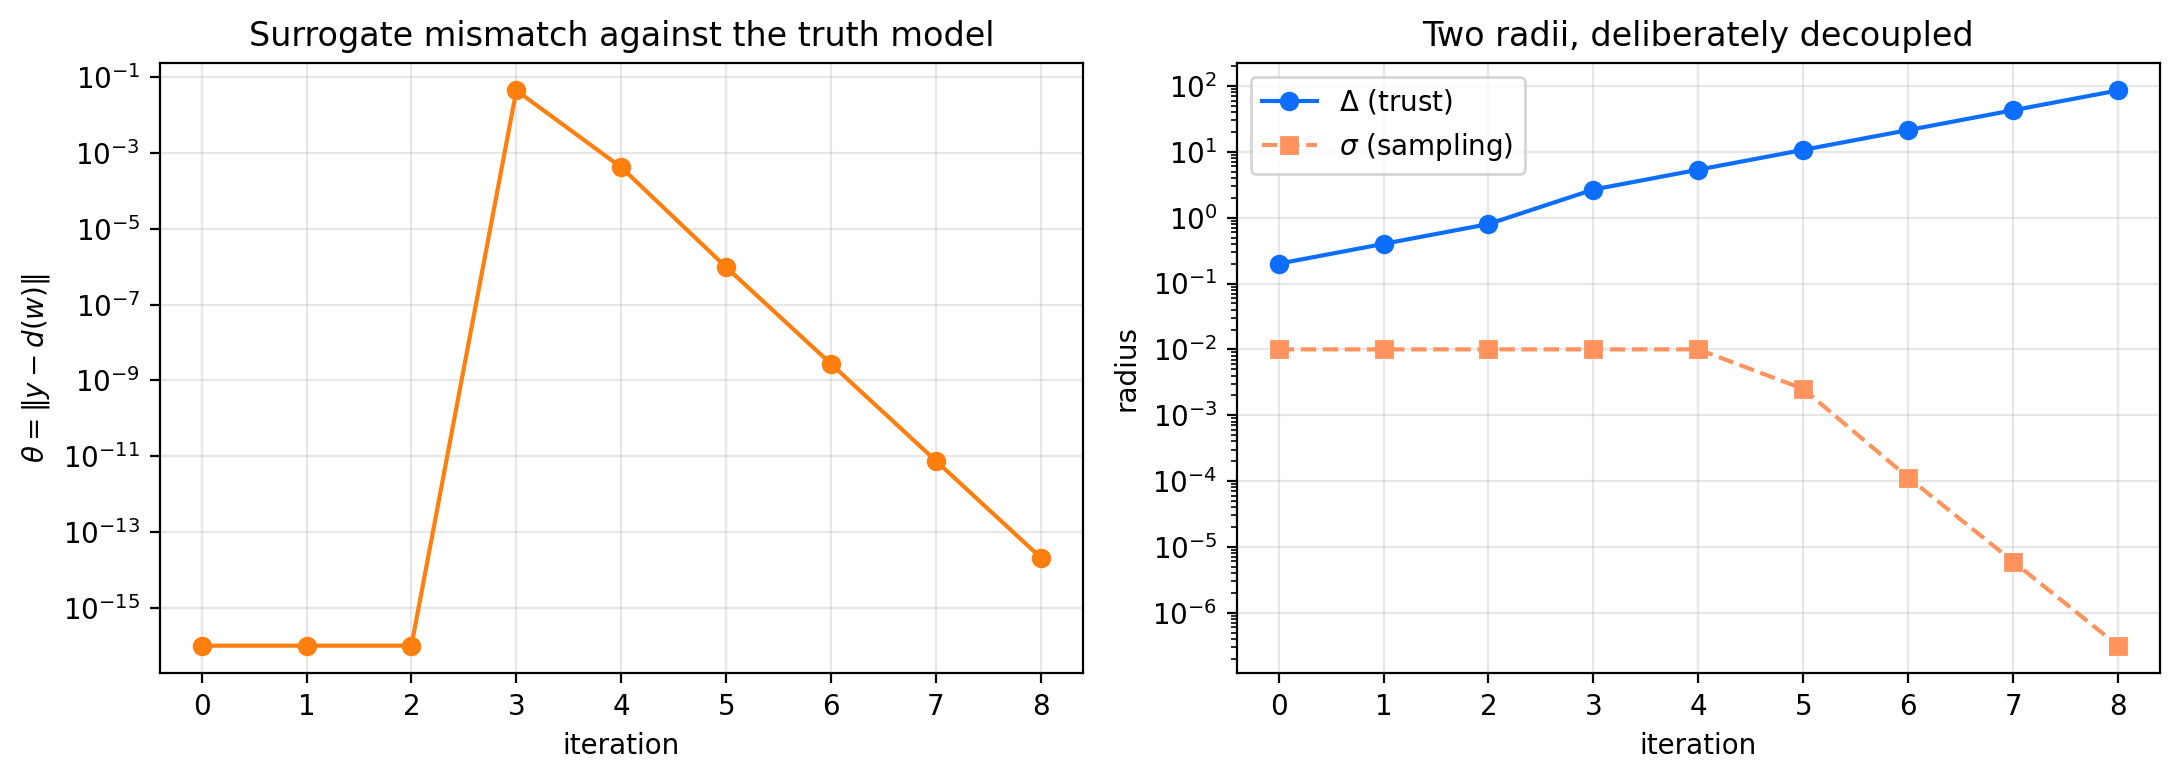

    0  incompatible       theta=0.000e+00  Delta=2.000e-01
    1  incompatible       theta=0.000e+00  Delta=4.000e-01
    2  incompatible       theta=0.000e+00  Delta=8.000e-01
    3  f-step             theta=4.513e-02  Delta=2.677e+00
    4  theta-step         theta=4.210e-04  Delta=5.354e+00
    5  theta-step         theta=9.736e-07  Delta=1.071e+01
    6  theta-step         theta=2.716e-09  Delta=2.142e+01
    7  theta-step         theta=7.512e-12  Delta=4.283e+01
    8  theta-step         theta=2.087e-14  Delta=8.567e+01


In [11]:
h = res1.history
k = [it.k for it in h]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))

a1.semilogy(k, [max(it.theta, 1e-16) for it in h], "o-", color="tab:orange")
a1.set_xlabel("iteration"); a1.set_ylabel(r"$\theta = \|y - d(w)\|$")
a1.set_title("Surrogate mismatch against the truth model")
a1.grid(alpha=0.3)

a2.semilogy(k, [it.trust_radius for it in h], "o-", label=r"$\Delta$ (trust)")
a2.semilogy(k, [it.sampling_radius for it in h], "s--", label=r"$\sigma$ (sampling)")
a2.set_xlabel("iteration"); a2.set_ylabel("radius")
a2.set_title("Two radii, deliberately decoupled")
a2.legend(); a2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

for it in h:
    print(f"  {it.k:3d}  {it.kind:<18} theta={it.theta:.3e}  Delta={it.trust_radius:.3e}")

The right-hand panel is Eason & Biegler's (2018) key structural change.
$\Delta$ bounds the **step**; $\sigma \le \Delta$ bounds where the surrogate is
**fit**. With one radius doing both jobs the algorithm is forced into tiny steps
near the solution purely to keep the model accurate — separating them more than
doubled the number of problems their test set could solve.

## Limitations

**Noise.** The truth model must be deterministic and smooth. Eason & Biegler
assume noise is negligible and list rigorous noise handling as open. For
optimization against *physical measurements*, use a noise-aware method such as
Bayesian optimization — this is the wrong tool.

**Local.** Converges to a *local* KKT point. Pair it with `pounce.find_minima`
(notebooks 19–21) for a multistart sweep.

**No restoration phase.** The published algorithm calls a restoration procedure
when the filter blocks every candidate step. This implementation does not have
one; it detects the resulting stall and reports `success=False` with a
`Stalled:` message rather than silently burning its iteration budget.

See [the TRF chapter](https://jkitchin.github.io/pounce/trf.html) for the full
API and tuning reference.